In [1]:
import os, random, h5py, cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.style.use("seaborn-v0_8")


2026-02-24 15:22:19.131268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771946539.339128      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771946539.400882      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771946539.905373      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771946539.905414      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771946539.905418      24 computation_placer.cc:177] computation placer alr

In [2]:
DATA_ROOT = "/kaggle/input/brats2020-training-data/BraTS2020_training_data/content/data"

h5_files = sorted([
    os.path.join(DATA_ROOT, f)
    for f in os.listdir(DATA_ROOT)
    if f.endswith(".h5")
])

print("Total HDF5 slice files:", len(h5_files))
assert len(h5_files) > 0


Total HDF5 slice files: 57195


In [3]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(
    h5_files,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print("Train slices:", len(train_files))
print("Val slices  :", len(val_files))


Train slices: 45756
Val slices  : 11439


In [4]:
def normalize_mri(img):
    img = img.astype(np.float32)
    nonzero = img[img > 0]
    if nonzero.size > 0:
        img = (img - nonzero.mean()) / (nonzero.std() + 1e-8)
    img[img == 0] = 0
    return img


In [5]:
def preprocess_slice(h5_path, size=128):
    with h5py.File(h5_path, "r") as f:
        img = f["image"][:]   # (240, 240, 4)
        mask = f["mask"][:]  # (240, 240, 3)

    # ----- IMAGE -----
    img = img.astype(np.float32)

    # Select modality (FLAIR is best for tumor visibility)
    img = img[:, :, 0]

    img = cv2.resize(img, (size, size))
    img = normalize_mri(img)

    # ----- MASK -----
    mask = mask.astype(np.uint8)

    # Merge WT / TC / ET → binary tumor mask
    mask = np.max(mask, axis=-1)

    mask = cv2.resize(mask, (size, size))
    mask = (mask > 0).astype(np.float32)

    return img[..., None], mask[..., None]


In [6]:
def load_segmentation_data(file_list):
    X, Y = [], []
    rejected = 0

    for fpath in file_list:
        try:
            img, mask = preprocess_slice(fpath)
            X.append(img)
            Y.append(mask)
        except Exception as e:
            rejected += 1

    print(f"Loaded slices  : {len(X)}")
    print(f"Rejected files: {rejected}")

    return np.array(X), np.array(Y)


In [7]:
X_tr_seg, Y_tr_seg = load_segmentation_data(train_files)
X_va_seg, Y_va_seg = load_segmentation_data(val_files)

print("Train shape:", X_tr_seg.shape, Y_tr_seg.shape)
print("Val shape  :", X_va_seg.shape, Y_va_seg.shape)

assert len(X_tr_seg) > 0 and len(X_va_seg) > 0


Loaded slices  : 45756
Rejected files: 0
Loaded slices  : 11439
Rejected files: 0
Train shape: (45756, 128, 128, 1) (45756, 128, 128, 1)
Val shape  : (11439, 128, 128, 1) (11439, 128, 128, 1)


Total tumor-positive slices: 19254


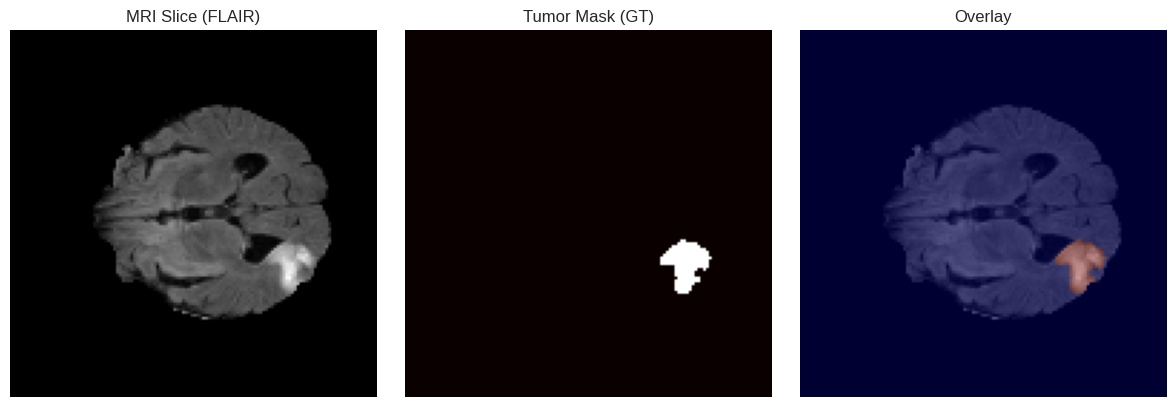

In [8]:
# ===============================
# Tumor-aware qualitative visualization
# ===============================

# find indices where tumor exists
tumor_indices = np.where(Y_tr_seg.sum(axis=(1,2,3)) > 0)[0]

print("Total tumor-positive slices:", len(tumor_indices))

# randomly pick one tumor slice
idx = np.random.choice(tumor_indices)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_tr_seg[idx].squeeze(), cmap="gray")
plt.title("MRI Slice (FLAIR)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_tr_seg[idx].squeeze(), cmap="hot")
plt.title("Tumor Mask (GT)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(X_tr_seg[idx].squeeze(), cmap="gray")
plt.imshow(Y_tr_seg[idx].squeeze(), cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()


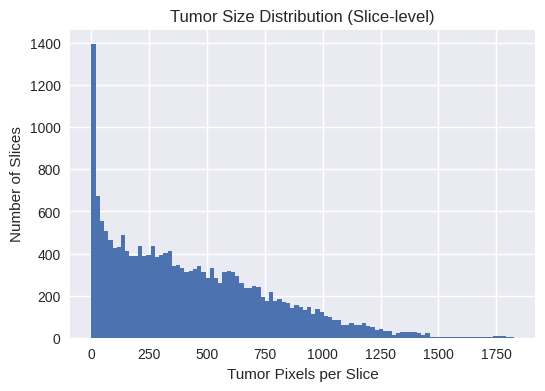

In [9]:
tumor_pixels = Y_tr_seg.sum(axis=(1,2,3))

plt.figure(figsize=(6,4))
plt.hist(tumor_pixels[tumor_pixels > 0], bins=100)
plt.xlabel("Tumor Pixels per Slice")
plt.ylabel("Number of Slices")
plt.title("Tumor Size Distribution (Slice-level)")
plt.show()


In [10]:
import tensorflow.keras.backend as K

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    return (2*inter + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    inter = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - inter
    return (inter + smooth) / (union + smooth)


In [11]:
from tensorflow.keras import layers, models

def build_unet(input_shape=(128,128,1)):
    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    c1 = layers.Conv2D(32,3,activation='relu',padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(p1)
    c2 = layers.Conv2D(64,3,activation='relu',padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    b = layers.Conv2D(128,3,activation='relu',padding='same')(p2)
    b = layers.Conv2D(128,3,activation='relu',padding='same')(b)

    u1 = layers.UpSampling2D()(b)
    u1 = layers.Concatenate()([u1,c2])
    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(u1)
    c3 = layers.Conv2D(64,3,activation='relu',padding='same')(c3)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.Concatenate()([u2,c1])
    c4 = layers.Conv2D(32,3,activation='relu',padding='same')(u2)
    c4 = layers.Conv2D(32,3,activation='relu',padding='same')(c4)

    outputs = layers.Conv2D(1,1,activation='sigmoid')(c4)
    return models.Model(inputs, outputs)


In [12]:
seg_model = build_unet()
seg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=dice_loss,
    metrics=[dice_coef, iou_coef]
)

seg_hist = seg_model.fit(
    X_tr_seg, Y_tr_seg,
    validation_data=(X_va_seg, Y_va_seg),
    epochs=25,
    batch_size=16
)


I0000 00:00:1771947734.820069      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771947734.825793      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/25


I0000 00:00:1771947752.834350      72 service.cc:152] XLA service 0x79a820006c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771947752.834392      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771947752.834396      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771947753.540722      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-24 15:42:36.825023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:42:37.099836: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:42:38.118553: E external/local_xl

   2/2860 ━━━━━━━━━━━━━━━━━━━━ 2:33 54ms/step - dice_coef: 0.0254 - iou_coef: 0.0129 - loss: 0.9746   

I0000 00:00:1771947763.751060      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2859/2860 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - dice_coef: 0.7023 - iou_coef: 0.5759 - loss: 0.2977

2026-02-24 15:45:12.817521: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:45:13.093275: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:45:14.158098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:45:14.456064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-24 15:45:14.771486: E external/local_xla/xla/stream_

2860/2860 ━━━━━━━━━━━━━━━━━━━━ 187s 60ms/step - dice_coef: 0.7024 - iou_coef: 0.5760 - loss: 0.2976 - val_dice_coef: 0.8385 - val_iou_coef: 0.7279 - val_loss: 0.1615
Epoch 2/25
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 166s 58ms/step - dice_coef: 0.8321 - iou_coef: 0.7203 - loss: 0.1679 - val_dice_coef: 0.8565 - val_iou_coef: 0.7542 - val_loss: 0.1435
Epoch 3/25
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 165s 58ms/step - dice_coef: 0.8504 - iou_coef: 0.7465 - loss: 0.1496 - val_dice_coef: 0.8677 - val_iou_coef: 0.7708 - val_loss: 0.1323
Epoch 4/25
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 165s 58ms/step - dice_coef: 0.8567 - iou_coef: 0.7553 - loss: 0.1433 - val_dice_coef: 0.8725 - val_iou_coef: 0.7783 - val_loss: 0.1275
Epoch 5/25
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 165s 58ms/step - dice_coef: 0.8718 - iou_coef: 0.7779 - loss: 0.1282 - val_dice_coef: 0.8797 - val_iou_coef: 0.7890 - val_loss: 0.1203
Epoch 6/25
2860/2860 ━━━━━━━━━━━━━━━━━━━━ 165s 58ms/step - dice_coef: 0.8800 - iou_coef: 0.7904 - loss: 0.1200 - val_dice_coef

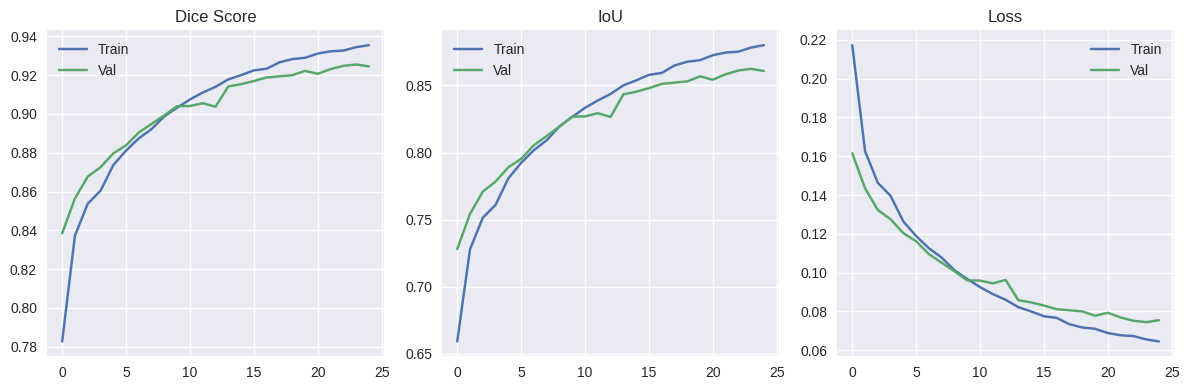

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(seg_hist.history["dice_coef"], label="Train")
plt.plot(seg_hist.history["val_dice_coef"], label="Val")
plt.title("Dice Score")
plt.legend()

plt.subplot(1,3,2)
plt.plot(seg_hist.history["iou_coef"], label="Train")
plt.plot(seg_hist.history["val_iou_coef"], label="Val")
plt.title("IoU")
plt.legend()

plt.subplot(1,3,3)
plt.plot(seg_hist.history["loss"], label="Train")
plt.plot(seg_hist.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# FINAL VALIDATION PERFORMANCE (Segmentation Model)
# ============================================================

val_results = seg_model.evaluate(
    X_va_seg,
    Y_va_seg,
    batch_size=16,
    verbose=1
)

# unpack metrics (order must match model.compile)
val_loss  = val_results[0]
val_dice  = val_results[1]
val_iou   = val_results[2]

print("\nSEGMENTATION PERFORMANCE ON VALIDATION SET")
print("------------------------------------------------")
print(f"Validation Dice Coefficient : {val_dice:.4f}")
print(f"Validation IoU              : {val_iou:.4f}")
print(f"Validation Loss             : {val_loss:.4f}")


715/715 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - dice_coef: 0.9247 - iou_coef: 0.8611 - loss: 0.0753

SEGMENTATION PERFORMANCE ON VALIDATION SET
------------------------------------------------
Validation Dice Coefficient : 0.9245
Validation IoU              : 0.8607
Validation Loss             : 0.0755


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


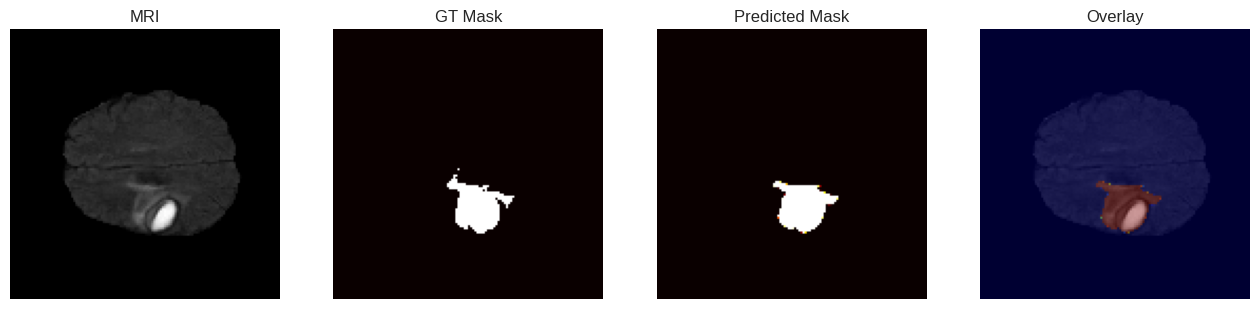

In [15]:
idx = np.random.choice(np.where(Y_va_seg.sum(axis=(1,2,3))>0)[0])
pred = seg_model.predict(X_va_seg[idx:idx+1])[0]

plt.figure(figsize=(16,4))

titles = ["MRI","GT Mask","Predicted Mask","Overlay"]
images = [
    X_va_seg[idx].squeeze(),
    Y_va_seg[idx].squeeze(),
    pred.squeeze(),
    None
]

for i in range(4):
    plt.subplot(1,4,i+1)
    if i < 3:
        plt.imshow(images[i], cmap="gray" if i==0 else "hot")
    else:
        plt.imshow(X_va_seg[idx].squeeze(), cmap="gray")
        plt.imshow(pred.squeeze(), cmap="jet", alpha=0.4)
    plt.title(titles[i])
    plt.axis("off")

plt.show()


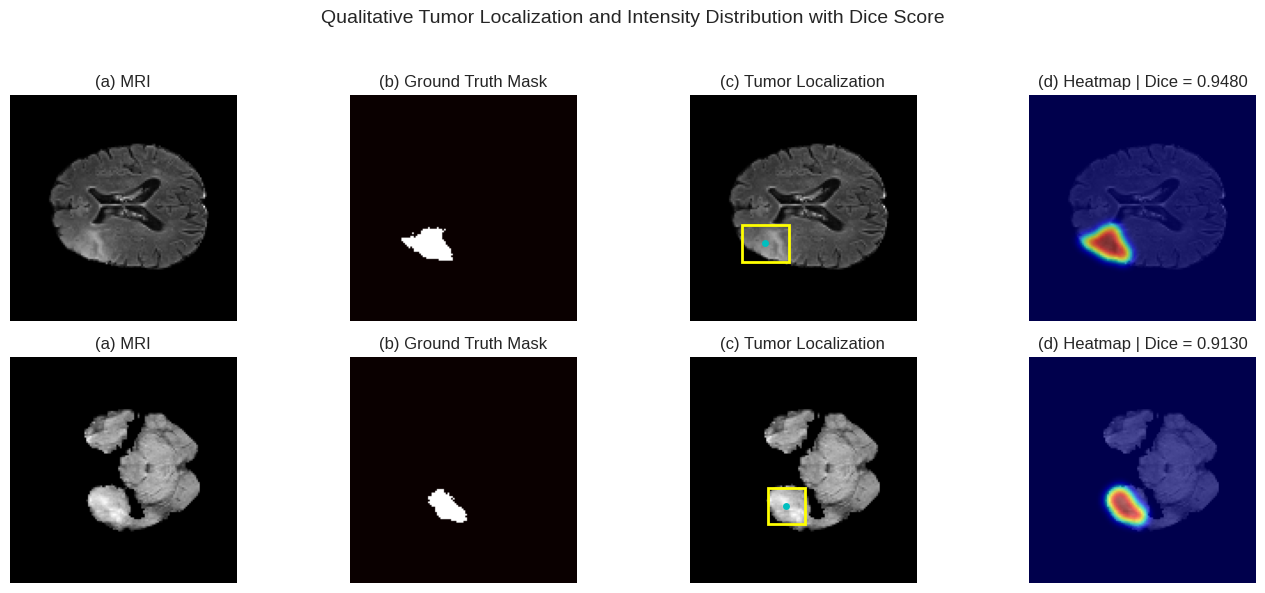

In [16]:
import matplotlib.patches as patches
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Dice score function
# -------------------------------
def dice_score(y_true, y_pred, eps=1e-8):
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + eps) / (np.sum(y_true) + np.sum(y_pred) + eps)

# ===============================
# Select tumor-positive samples
# ===============================
tumor_idxs = np.where(Y_va_seg.sum(axis=(1,2,3)) > 0)[0]
sample_idxs = np.random.choice(tumor_idxs, 2, replace=False)

plt.figure(figsize=(14,6))

for row, idx in enumerate(sample_idxs):

    # MRI & GT
    img = X_va_seg[idx].squeeze()
    gt  = Y_va_seg[idx].squeeze()

    # Predict segmentation
    pred = seg_model.predict(X_va_seg[idx:idx+1], verbose=0)[0].squeeze()
    pred_bin = (pred > 0.5).astype(np.uint8)

    # -------------------------------
    # Dice score
    # -------------------------------
    dice = dice_score(gt, pred_bin)

    # -------------------------------
    # Tumor bounding box (safe)
    # -------------------------------
    ys, xs = np.where(pred_bin > 0)
    if len(xs) > 0:
        y1, y2 = ys.min(), ys.max()
        x1, x2 = xs.min(), xs.max()
    else:
        y1 = y2 = x1 = x2 = None

    # -------------------------------
    # Heatmap
    # -------------------------------
    heatmap = cv2.GaussianBlur(pred, (15,15), 0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # ---------- (a) MRI ----------
    ax1 = plt.subplot(2,4,row*4 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title("(a) MRI")
    ax1.axis("off")

    # ---------- (b) Tumor Mask ----------
    ax2 = plt.subplot(2,4,row*4 + 2)
    ax2.imshow(gt, cmap="hot")
    ax2.set_title("(b) Ground Truth Mask")
    ax2.axis("off")

    # ---------- (c) Tumor Localization ----------
    ax3 = plt.subplot(2,4,row*4 + 3)
    ax3.imshow(img, cmap="gray")

    if x1 is not None:
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="yellow", facecolor="none"
        )
        ax3.add_patch(rect)
        ax3.plot((x1+x2)//2, (y1+y2)//2, "co", markersize=5)

    ax3.set_title("(c) Tumor Localization")
    ax3.axis("off")

    # ---------- (d) Tumor Heatmap ----------
    ax4 = plt.subplot(2,4,row*4 + 4)
    ax4.imshow(img, cmap="gray")
    ax4.imshow(heatmap, cmap="jet", alpha=0.6)
    ax4.set_title(f"(d) Heatmap | Dice = {dice:.4f}")
    ax4.axis("off")

plt.suptitle(
    "Qualitative Tumor Localization and Intensity Distribution with Dice Score",
    fontsize=14
)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [17]:
# ===============================
# Batch prediction for segmentation
# ===============================
Y_va_pred = seg_model.predict(X_va_seg, batch_size=16, verbose=1)
Y_va_bin  = (Y_va_pred > 0.5).astype(np.float32)


715/715 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step


In [18]:
def compute_metrics(y_true, y_pred, eps=1e-6):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    tp = np.sum(y_true * y_pred)
    fp = np.sum((1 - y_true) * y_pred)
    fn = np.sum(y_true * (1 - y_pred))
    tn = np.sum((1 - y_true) * (1 - y_pred))

    dice = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou  = (tp + eps) / (tp + fp + fn + eps)
    sens = (tp + eps) / (tp + fn + eps)
    spec = (tn + eps) / (tn + fp + eps)

    return dice, iou, sens, spec


In [19]:
dice_scores, iou_scores, sens_scores, spec_scores = [], [], [], []

for i in range(len(Y_va_seg)):
    if Y_va_seg[i].sum() == 0:
        continue  # standard practice: tumor-positive slices only

    d,iou,sn,sp = compute_metrics(
        Y_va_seg[i].squeeze(),
        Y_va_bin[i].squeeze()
    )

    dice_scores.append(d)
    iou_scores.append(iou)
    sens_scores.append(sn)
    spec_scores.append(sp)

print("SEGMENTATION PERFORMANCE (Validation)")
print("-------------------------------------")
print(f"Dice        : {np.mean(dice_scores):.4f} ± {np.std(dice_scores):.4f}")
print(f"IoU         : {np.mean(iou_scores):.4f} ± {np.std(iou_scores):.4f}")
print(f"Sensitivity : {np.mean(sens_scores):.4f}")
print(f"Specificity : {np.mean(spec_scores):.4f}")


SEGMENTATION PERFORMANCE (Validation)
-------------------------------------
Dice        : 0.7846 ± 0.3109
IoU         : 0.7225 ± 0.3040
Sensitivity : 0.7763
Specificity : 0.9985


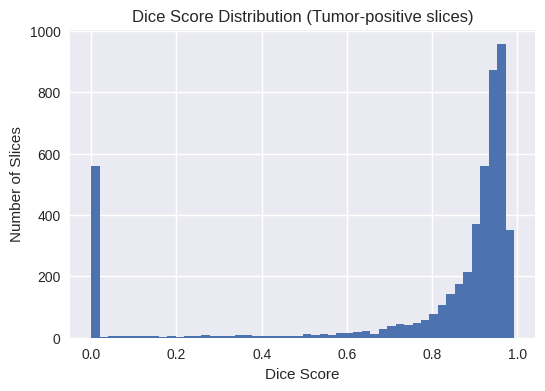

In [20]:
plt.figure(figsize=(6,4))
plt.hist(dice_scores, bins=50)
plt.xlabel("Dice Score")
plt.ylabel("Number of Slices")
plt.title("Dice Score Distribution (Tumor-positive slices)")
plt.show()


In [21]:
# Tumor presence label from GT mask
y_tr_presence = (Y_tr_seg.sum(axis=(1,2,3)) > 0).astype(int)
y_va_presence = (Y_va_seg.sum(axis=(1,2,3)) > 0).astype(int)

print("Train tumor-positive slices:", y_tr_presence.sum())
print("Train tumor-negative slices:", (y_tr_presence == 0).sum())


Train tumor-positive slices: 19254
Train tumor-negative slices: 26502


In [22]:
# ===============================
# ROI Extraction for Classification
# ===============================

X_tr_cls, y_tr_cls = [], []
X_va_cls, y_va_cls = [], []

# Predict segmentation masks
Y_tr_pred = seg_model.predict(X_tr_seg, batch_size=16, verbose=1)
Y_va_pred = seg_model.predict(X_va_seg, batch_size=16, verbose=1)

Y_tr_bin = (Y_tr_pred > 0.5).astype(np.uint8)
Y_va_bin = (Y_va_pred > 0.5).astype(np.uint8)

# -------------------------------
# Utility functions
# -------------------------------
def center_crop(img, size=64):
    """Fallback crop for negative samples"""
    h, w = img.shape
    cy, cx = h // 2, w // 2
    s = size // 2
    return img[cy-s:cy+s, cx-s:cx+s][..., None]

def extract_roi(img, mask, size=64):
    """
    Extract ROI from segmentation mask.
    Returns fixed-size crop or None if invalid.
    """
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None

    y1, y2 = ys.min(), ys.max()
    x1, x2 = xs.min(), xs.max()

    # Expand small regions
    if (y2 - y1) < 10 or (x2 - x1) < 10:
        return None

    roi = img[y1:y2, x1:x2]

    # Resize ROI to fixed size
    roi = cv2.resize(roi, (size, size), interpolation=cv2.INTER_LINEAR)
    return roi[..., None]

# ===============================
# BUILD CLASSIFICATION DATA
# ===============================

# -------- TRAIN --------
for i in range(len(X_tr_seg)):
    img = X_tr_seg[i].squeeze()

    if y_tr_presence[i] == 1:
        roi = extract_roi(img, Y_tr_bin[i].squeeze())
        if roi is not None:
            X_tr_cls.append(roi)
            y_tr_cls.append(1)
        else:
            # fallback if mask fails
            X_tr_cls.append(center_crop(img))
            y_tr_cls.append(1)
    else:
        X_tr_cls.append(center_crop(img))
        y_tr_cls.append(0)

# -------- VALIDATION --------
for i in range(len(X_va_seg)):
    img = X_va_seg[i].squeeze()

    if y_va_presence[i] == 1:
        roi = extract_roi(img, Y_va_bin[i].squeeze())
        if roi is not None:
            X_va_cls.append(roi)
            y_va_cls.append(1)
        else:
            X_va_cls.append(center_crop(img))
            y_va_cls.append(1)
    else:
        X_va_cls.append(center_crop(img))
        y_va_cls.append(0)

# Convert to arrays
X_tr_cls = np.array(X_tr_cls, dtype=np.float32)
X_va_cls = np.array(X_va_cls, dtype=np.float32)
y_tr_cls = np.array(y_tr_cls)
y_va_cls = np.array(y_va_cls)

print("Train:", X_tr_cls.shape, np.bincount(y_tr_cls))
print("Val  :", X_va_cls.shape, np.bincount(y_va_cls))


2860/2860 ━━━━━━━━━━━━━━━━━━━━ 40s 14ms/step
715/715 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step
Train: (45756, 64, 64, 1) [26502 19254]
Val  : (11439, 64, 64, 1) [6519 4920]


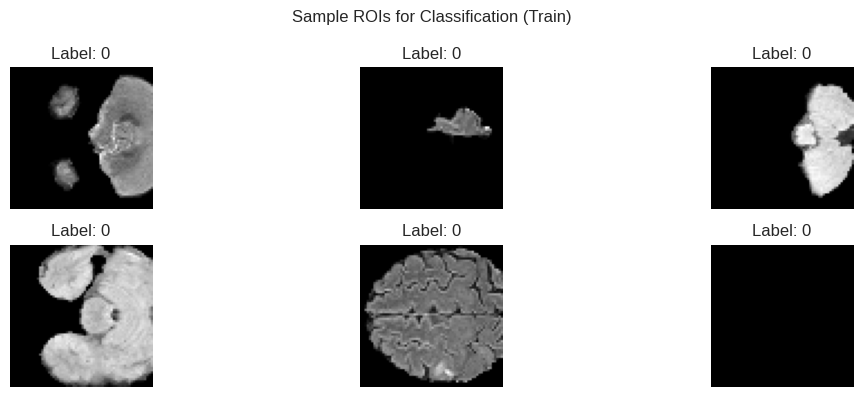

In [23]:
# ===============================
# Visual sanity check of ROIs
# ===============================
import matplotlib.pyplot as plt

idxs = np.random.choice(len(X_tr_cls), 6, replace=False)

plt.figure(figsize=(12,4))
for i, idx in enumerate(idxs):
    plt.subplot(2,3,i+1)
    plt.imshow(X_tr_cls[idx].squeeze(), cmap="gray")
    plt.title(f"Label: {y_tr_cls[idx]}")
    plt.axis("off")

plt.suptitle("Sample ROIs for Classification (Train)")
plt.tight_layout()
plt.show()


In [24]:
# ===============================
# CNN Classifier (ROI-based)
# ===============================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

clf_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(64,64,1)),
    MaxPooling2D(2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

clf_model.compile(
    optimizer=Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

clf_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 682,753 (2.60 MB)

 Trainable params: 682,753 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ===============================
# Train classifier
# ===============================
history_cls = clf_model.fit(
    X_tr_cls, y_tr_cls,
    validation_data=(X_va_cls, y_va_cls),
    epochs=25,
    batch_size=64,
    verbose=1
)


Epoch 1/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.9008 - loss: 0.2873 - val_accuracy: 0.9128 - val_loss: 0.2005
Epoch 2/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9241 - loss: 0.1798 - val_accuracy: 0.9282 - val_loss: 0.1685
Epoch 3/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9344 - loss: 0.1584 - val_accuracy: 0.9375 - val_loss: 0.1507
Epoch 4/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9424 - loss: 0.1424 - val_accuracy: 0.9441 - val_loss: 0.1405
Epoch 5/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9493 - loss: 0.1301 - val_accuracy: 0.9503 - val_loss: 0.1285
Epoch 6/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9532 - loss: 0.1216 - val_accuracy: 0.9531 - val_loss: 0.1195
Epoch 7/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9563 - loss: 0.1101 - val_accuracy: 0.9579 - val_loss: 0.1110
Epoch 8/25
715/715 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9625 - loss: 0.0977 - val_accuracy: 

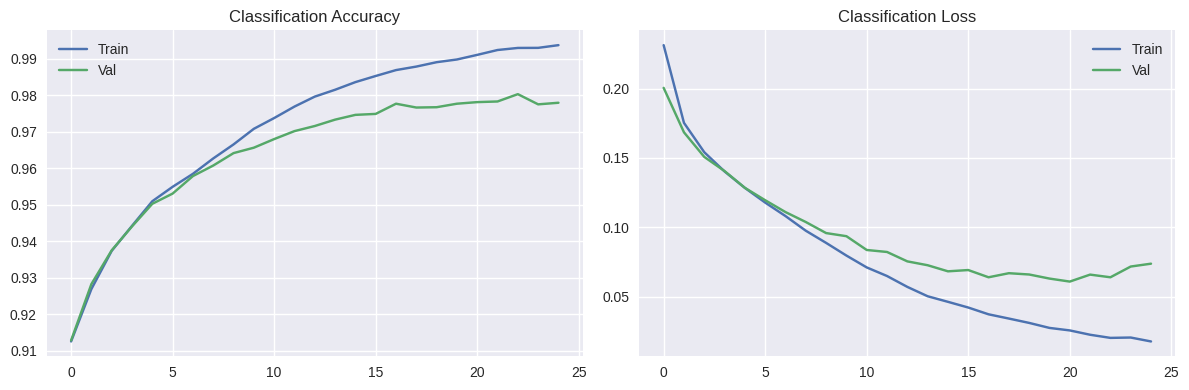

In [26]:
# ===============================
# Plot training curves
# ===============================
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_cls.history["accuracy"], label="Train")
plt.plot(history_cls.history["val_accuracy"], label="Val")
plt.title("Classification Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cls.history["loss"], label="Train")
plt.plot(history_cls.history["val_loss"], label="Val")
plt.title("Classification Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [27]:
# ===============================
# Test set evaluation
# ===============================
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

y_va_prob = clf_model.predict(X_va_cls).ravel()
y_va_pred = (y_va_prob > 0.5).astype(int)

print("TEST CLASSIFICATION RESULTS")
print("----------------------------")
print("Accuracy  :", accuracy_score(y_va_cls, y_va_pred))
print("Precision :", precision_score(y_va_cls, y_va_pred))
print("Recall    :", recall_score(y_va_cls, y_va_pred))
print("F1-score  :", f1_score(y_va_cls, y_va_pred))
print("ROC-AUC   :", roc_auc_score(y_va_cls, y_va_prob))


358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
TEST CLASSIFICATION RESULTS
----------------------------
Accuracy  : 0.977970102281668
Precision : 0.989513422818792
Recall    : 0.9589430894308943
F1-score  : 0.9739884393063584
ROC-AUC   : 0.9973560399432803


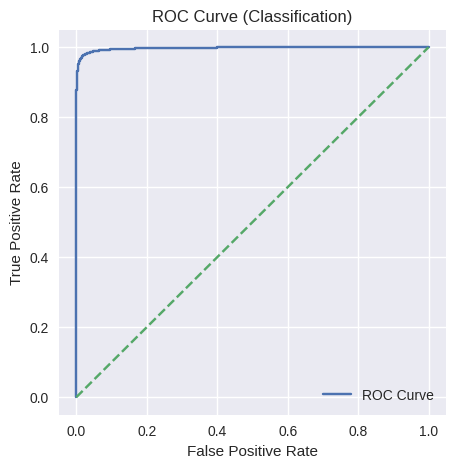

In [28]:
# ===============================
# ROC Curve
# ===============================
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_va_cls, y_va_prob)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Classification)")
plt.legend()
plt.show()


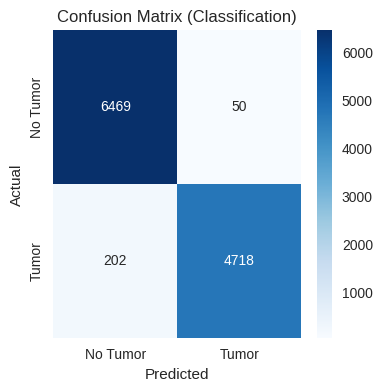

In [29]:
# ===============================
# Confusion Matrix
# ===============================
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_va_cls, y_va_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Tumor","Tumor"],
            yticklabels=["No Tumor","Tumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Classification)")
plt.show()


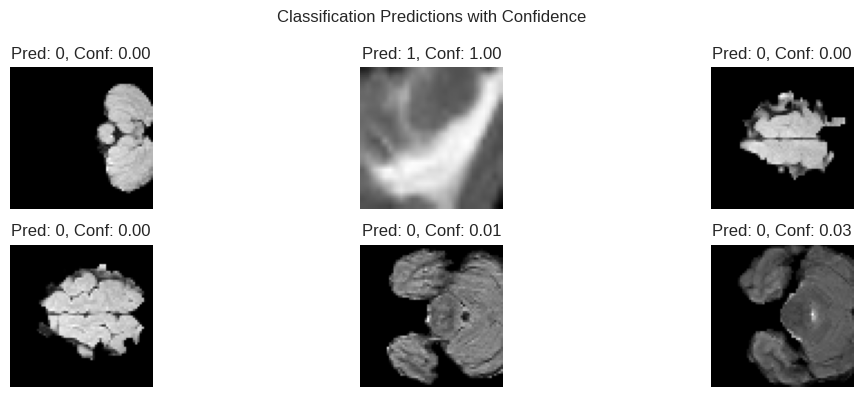

In [30]:
# ===============================
# Random predictions with confidence
# ===============================
idxs = np.random.choice(len(X_va_cls), 6, replace=False)

plt.figure(figsize=(12,4))
for i, idx in enumerate(idxs):
    prob = y_va_prob[idx]
    pred = y_va_pred[idx]

    plt.subplot(2,3,i+1)
    plt.imshow(X_va_cls[idx].squeeze(), cmap="gray")
    plt.title(f"Pred: {pred}, Conf: {prob:.2f}")
    plt.axis("off")

plt.suptitle("Classification Predictions with Confidence")
plt.tight_layout()
plt.show()


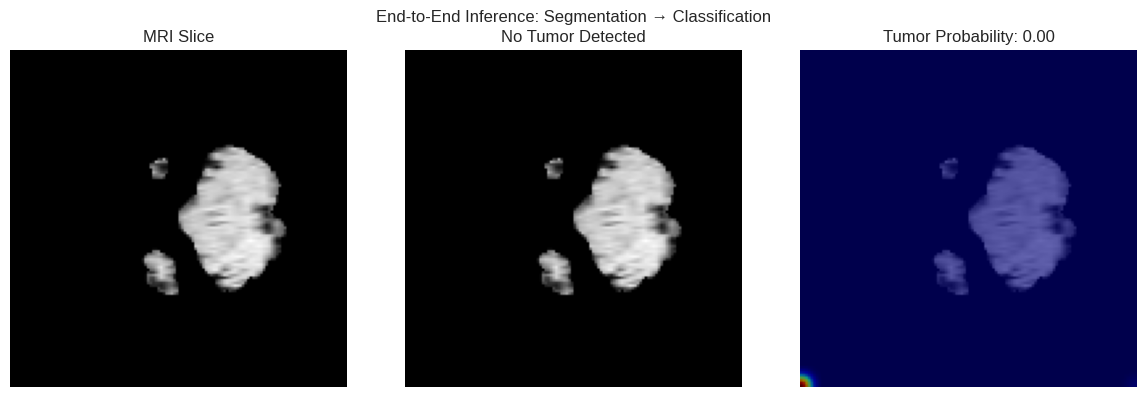

In [31]:
# ===============================
# End-to-End qualitative test (SAFE VERSION)
# ===============================
import matplotlib.patches as patches

idx = np.random.choice(len(X_va_seg))

img = X_va_seg[idx].squeeze()
gt  = Y_va_seg[idx].squeeze()

# ---------- Segmentation ----------
pred_mask = seg_model.predict(X_va_seg[idx:idx+1], verbose=0)[0].squeeze()
pred_bin  = (pred_mask > 0.5).astype(np.uint8)

# ---------- Check if tumor detected ----------
ys, xs = np.where(pred_bin > 0)

has_tumor = len(xs) > 0 and len(ys) > 0

# ---------- ROI + Classification ----------
cls_prob = 0.0
if has_tumor:
    roi = extract_roi(img, pred_bin)
    if roi is not None:
        cls_prob = clf_model.predict(roi[None, ...], verbose=0)[0][0]

# ---------- Heatmap ----------
heatmap = cv2.GaussianBlur(pred_mask, (15,15), 0)
heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)

# ===============================
# Visualization
# ===============================
plt.figure(figsize=(12,4))

# (1) MRI
plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("MRI Slice")
plt.axis("off")

# (2) Segmentation (only if exists)
plt.subplot(1,3,2)
plt.imshow(img, cmap="gray")
if has_tumor:
    plt.imshow(pred_bin, cmap="hot", alpha=0.5)
    plt.title("Predicted Segmentation")
else:
    plt.title("No Tumor Detected")
plt.axis("off")

# (3) Heatmap + Classification
plt.subplot(1,3,3)
plt.imshow(img, cmap="gray")
plt.imshow(heatmap, cmap="jet", alpha=0.6)
plt.title(f"Tumor Probability: {cls_prob:.2f}")
plt.axis("off")

plt.suptitle("End-to-End Inference: Segmentation → Classification")
plt.tight_layout()
plt.show()


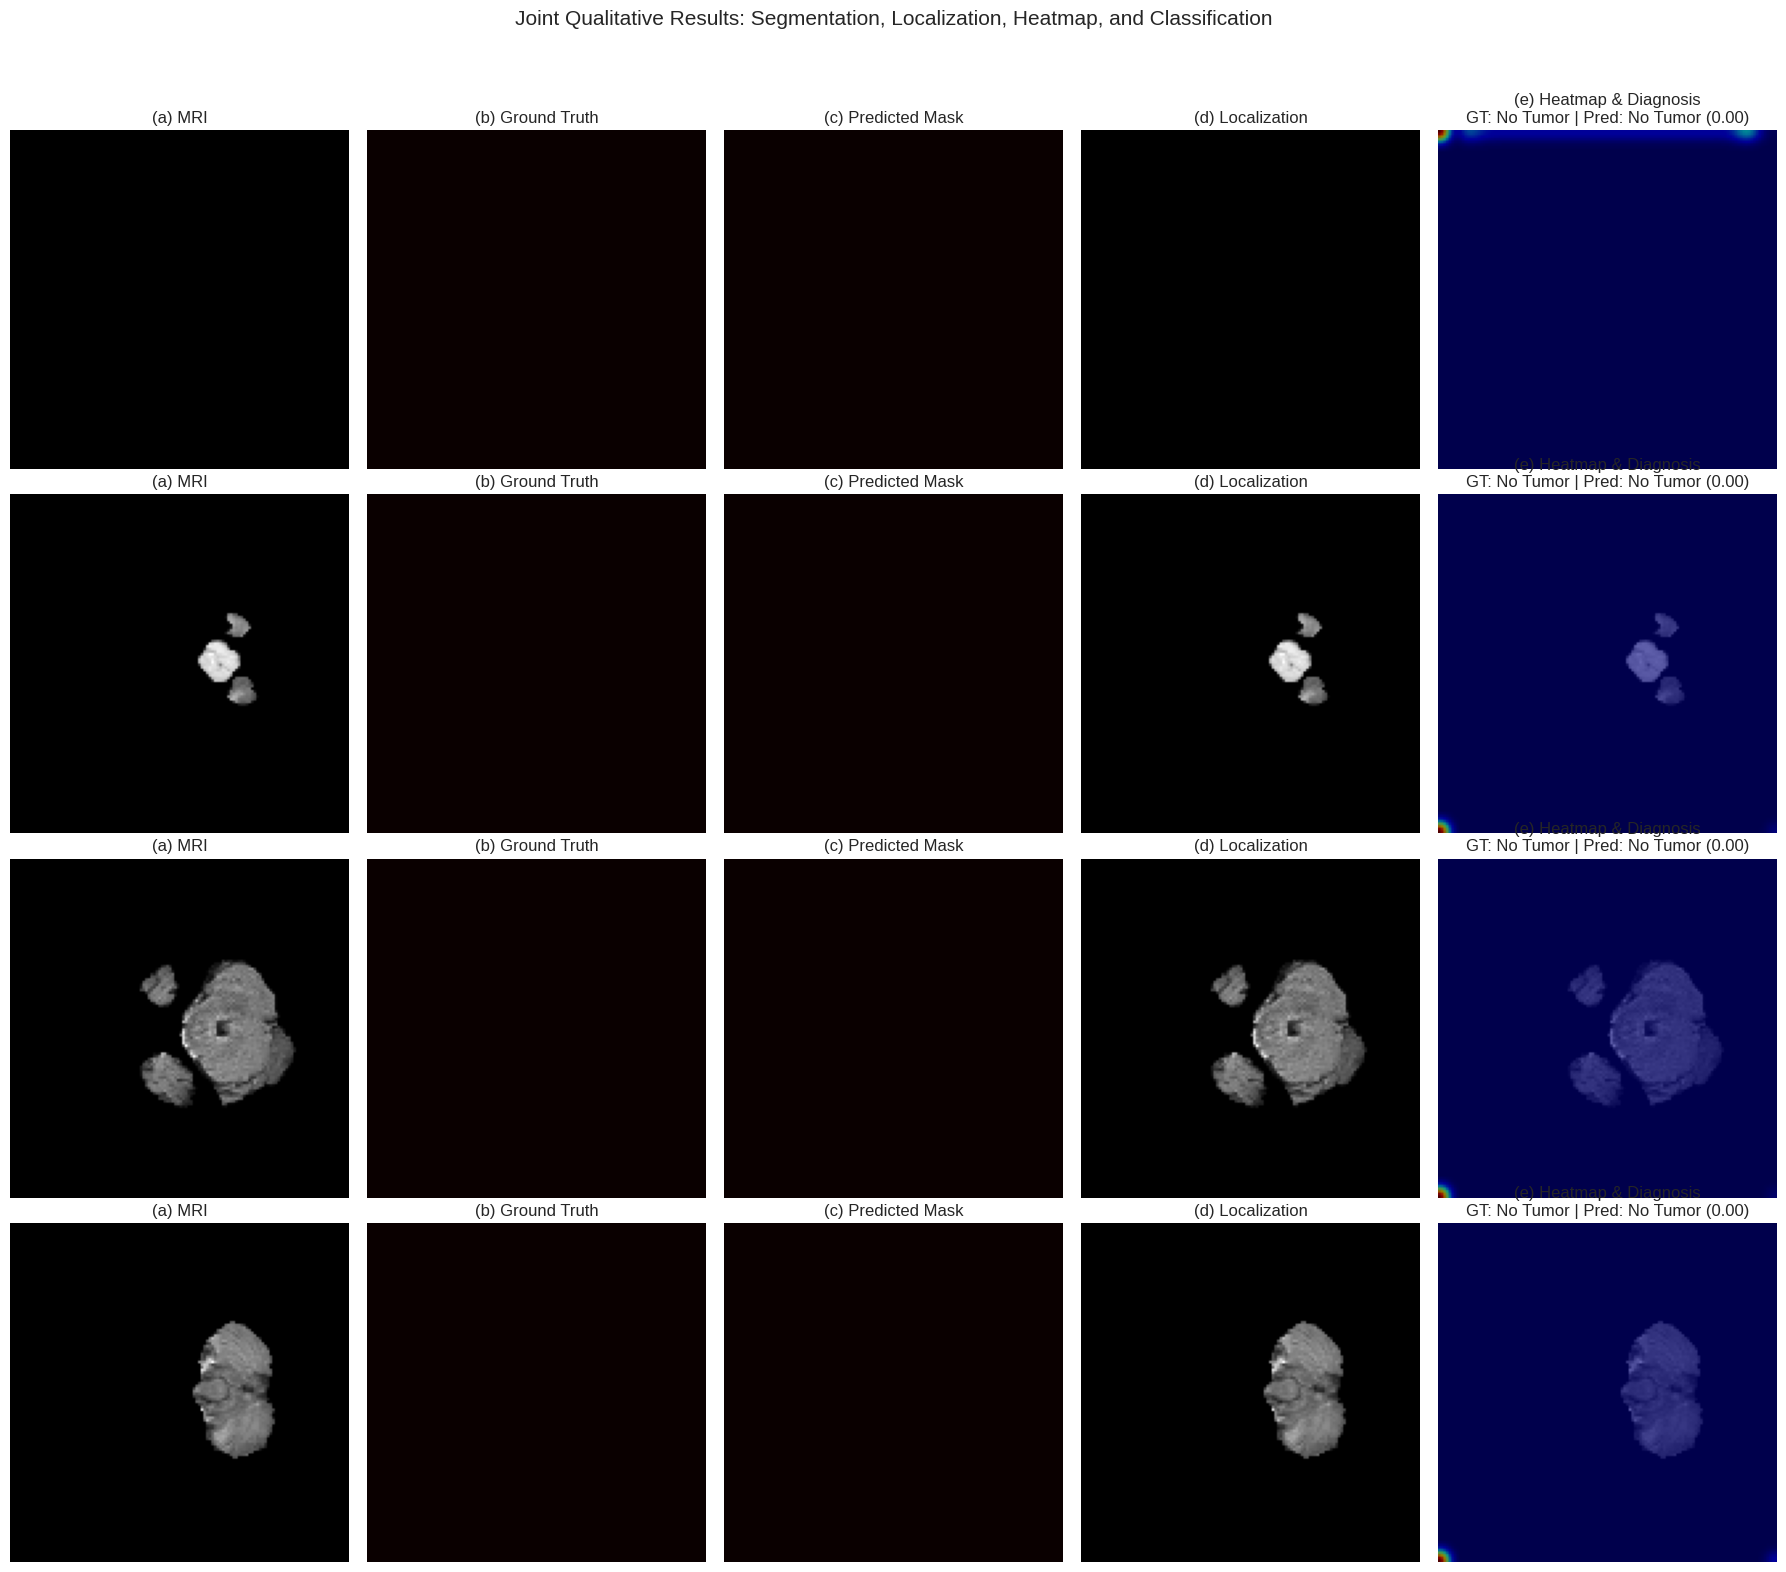

In [32]:
# ============================================================
# FINAL QUALITATIVE TEST
# Segmentation + Localization + Classification (FIXED)
# ============================================================

import matplotlib.patches as patches
import cv2
import numpy as np
import matplotlib.pyplot as plt

N_SAMPLES = 4
idxs = np.random.choice(len(X_va_seg), N_SAMPLES, replace=False)

plt.figure(figsize=(18, 4 * N_SAMPLES))

for row, idx in enumerate(idxs):

    # -------------------------
    # Input & ground truth
    # -------------------------
    img = X_va_seg[idx].squeeze()
    gt_mask = Y_va_seg[idx].squeeze()
    gt_label = int(gt_mask.sum() > 0)

    # -------------------------
    # Segmentation prediction
    # -------------------------
    pred_prob = seg_model.predict(
        X_va_seg[idx:idx+1], verbose=0
    )[0].squeeze()

    pred_mask = (pred_prob > 0.5).astype(np.uint8)

    # -------------------------
    # Heatmap
    # -------------------------
    heatmap = cv2.GaussianBlur(pred_prob, (15, 15), 0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

    # -------------------------
    # Localization & classification
    # -------------------------
    ys, xs = np.where(pred_mask > 0)
    has_pred_tumor = len(xs) > 20

    cls_prob = 0.0
    cls_pred = 0

    if has_pred_tumor:
        y1, y2 = ys.min(), ys.max()
        x1, x2 = xs.min(), xs.max()

        roi = extract_roi(img, pred_mask)
        if roi is not None:
            cls_prob = clf_model.predict(
                roi[None, ...], verbose=0
            )[0, 0]
            cls_pred = int(cls_prob > 0.5)
    else:
        y1 = y2 = x1 = x2 = None

    # =========================
    # Visualization
    # =========================

    # (a) MRI
    ax1 = plt.subplot(N_SAMPLES, 5, row * 5 + 1)
    ax1.imshow(img, cmap="gray")
    ax1.set_title("(a) MRI")
    ax1.axis("off")

    # (b) Ground Truth Mask
    ax2 = plt.subplot(N_SAMPLES, 5, row * 5 + 2)
    ax2.imshow(gt_mask, cmap="hot")
    ax2.set_title("(b) Ground Truth")
    ax2.axis("off")

    # (c) Predicted Mask
    ax3 = plt.subplot(N_SAMPLES, 5, row * 5 + 3)
    ax3.imshow(pred_mask, cmap="hot")
    ax3.set_title("(c) Predicted Mask")
    ax3.axis("off")

    # (d) Localization
    ax4 = plt.subplot(N_SAMPLES, 5, row * 5 + 4)
    ax4.imshow(img, cmap="gray")

    if has_pred_tumor:
        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="yellow",
            facecolor="none"
        )
        ax4.add_patch(rect)
        ax4.plot((x1 + x2) // 2, (y1 + y2) // 2, "co", markersize=5)

    ax4.set_title("(d) Localization")
    ax4.axis("off")

    # (e) Heatmap + Classification
    ax5 = plt.subplot(N_SAMPLES, 5, row * 5 + 5)
    ax5.imshow(img, cmap="gray")
    ax5.imshow(heatmap, cmap="jet", alpha=0.6)

    ax5.set_title(
        "(e) Heatmap & Diagnosis\n"
        f"GT: {'Tumor' if gt_label else 'No Tumor'} | "
        f"Pred: {'Tumor' if cls_pred else 'No Tumor'} "
        f"({cls_prob:.2f})"
    )
    ax5.axis("off")

plt.suptitle(
    "Joint Qualitative Results: Segmentation, Localization, Heatmap, and Classification",
    fontsize=15
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
